In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from transformers import GPT2LMHeadModel

W0306 21:03:40.306000 38427 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [4]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")# 124m, [gpt2-xl: 1558M] params
sd_hf = model_hf.state_dict()

for k,v in sd_hf.items():
    print(k,v.shape)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [5]:
sd_hf['transformer.wpe.weight'].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

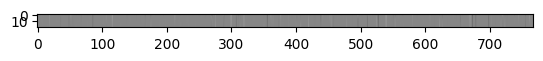

In [6]:
import matplotlib.pyplot as plt

plt.imshow(sd_hf['transformer.wpe.weight'][:20], cmap="gray")

This has structure as:
   - Every row is a input position on the input sequence
   - Learned from scratch, model recovers sinusodial-like structures over time
   - Early training shows noise, but it converges over time
   - More training would lead to a smoother noise

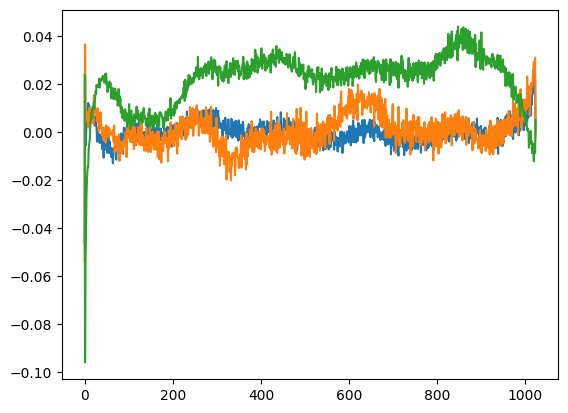

In [7]:
plt.plot(sd_hf['transformer.wpe.weight'][:,150])
plt.plot(sd_hf['transformer.wpe.weight'][:,200])
plt.plot(sd_hf['transformer.wpe.weight'][:,250])

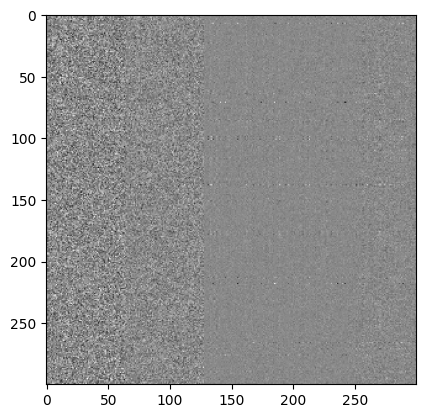

In [8]:
plt.imshow(sd_hf['transformer.h.1.attn.c_attn.weight'][:300,:300], cmap="gray")

In [9]:
## Sample from the model

In [10]:
from transformers import pipeline, set_seed
generator = pipeline("text-generation", model="gpt2")
set_seed(42)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [11]:
generator("Hello I am a language model", max_length = 30, num_return_sequences=5)

Passing `generation_config` together with generation-related arguments=({'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello I am a language modeler. I use the standard C++ compiler and I have the best C++ code I have ever seen. I have the best C++ code and I have the best C++ code. I am a very, very good programmer. I use a lot of different languages.\n\nI am a language modeler with really good intuition on what's needed to solve a problem in a language. I have learned a lot of things from my experience.\n\nI am a very, very good programmer. I use a lot of different languages.\n\nI am a very, very good programmer. I use a lot of different languages.\n\nI am a very, very good programmer. I use a lot of different languages.\n\nI am a very, very good programmer. I use a lot of different languages.\n\nI am a very, very good programmer. I use a lot of different languages.\n\nI am a very, very good programmer. I use a lot of different languages.\n\nI am a very, very good programmer. I use a lot of different languages.\n\nI am a very, very good programmer. I use a lot of different langua

## Own trained GPT2

In [12]:
import torch.nn as nn
import torch
from dataclasses import dataclass
import torch.nn.functional as F

In [13]:
class CasualSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embed % config.n_head == 0
        # Key, Value, Query for all heads but in one batch
        self.c_attn = nn.Linear(config.n_embed, 3 * config.n_embed)
        # output projection
        self.c_proj = nn.Linear(config.n_embed, config.n_embed)
        self.c_proj.NANOGPT_SCALE_INIT = 1

        self.n_head = config.n_head
        self.n_embd = config.n_embed

    def forward(self, x):
        B, T, C = x.size()  # batch size, sequence_len, embedding_dim n_embed
        # calculate the query, key and value for all heads in a batch and move forward to be the batch
        # nh is number of heads, hs is head size and c is number of channels
        # e.g. in GPT-2 (124M), n_heads = 12, hs=64, sonh*hs =C=768 in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # B,nh, T, ns
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # B,nh, T, ns
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)  # B,nh, T, ns
        # Attenion (materialisze the large T,T matrix for all the queryies and keys )
        # This is flash attention
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)

        y = (
            y.transpose(1, 2).contiguous().view(B, T, C)
        )  # Get back into the shape it came in
        return self.c_proj(y)


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embed, 4 * config.n_embed)
        self.gelu = nn.GELU(approximate="tanh")
        self.c_proj = nn.Linear(config.n_embed * 4, config.n_embed)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embed)
        self.attn = CasualSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embed)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))

        return x


@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = (
        50257  # number of tokens: 50,000 BPE merges = 256 byte tokens + 1 <|endoftext|>
    )
    n_layer: int = 12
    n_head: int = 12
    n_embed: int = 768


class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(
            dict(
                wte=nn.Embedding(config.vocab_size, config.n_embed),
                wpe=nn.Embedding(config.block_size, config.n_embed),
                h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
                ln_f=nn.LayerNorm(config.n_embed),
            )
        )
        self.lm_head = nn.Linear(config.n_embed, config.vocab_size, bias=False)
        # weight sharing
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, "NANOGPT_SCALE_INIT"):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx is always B,T
        B, T = idx.size()
        assert (
            T <= self.config.block_size
        ), f"Cannot forward sequence of length {T}, block size is {config.block_size}"
        # forward the token and position embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        pos_emb = self.transformer.wpe(pos)  # positional embeddings of shape T,N-embed
        tok_emb = self.transformer.wte(idx)  # token embedding of shape B,T,n_embed
        x = tok_emb + pos_emb
        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)
        # forward through final layernorm and classifier
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)  # B,T,Vocab_size
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained model GPT-2 Model weights from huggingface"""
        assert model_type in {"gpt2", "gpt2-medium", "gpt2-large", "gpt2-xl"}
        from transformers import GPT2LMHeadModel

        print(f"Loading weights from pretrained gpt: { model_type}")
        config_args = {
            "gpt2": dict(n_layer=12, n_head=12, n_embed=768),  # 124M params
            "gpt2-medium": dict(n_layer=24, n_head=16, n_embed=1024),  # 350M params
            "gpt2-large": dict(n_layer=36, n_head=20, n_embed=1280),  # 774M params
            "gpt2-xl": dict(n_layer=48, n_head=25, n_embed=1600),  # 1558M params
        }[model_type]
        config_args["vocab_size"] = 50257  # always this for GPT model checkpoints
        config_args["block_size"] = (
            1024  # always this sequence length for GPT chekpoints
        )
        # create a sfrom scratch intialised minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [
            k for k in sd_keys if not k.endswith(".attn.bias")
        ]  # discard this mask / buffer

        # init a huggingface transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()
        # copy while ensuring all of the parameters are aligned and match in name and shapes
        sd_hf_keys = sd_hf.keys()
        sd_hf_keys = [
            k for k in sd_hf_keys if not k.endswith(".attn.masked_bias")
        ]  # discard this mask / buffer
        sd_hf_keys = [
            k for k in sd_hf_keys if not k.endswith(".attn.bias")
        ]  # discard this mask / buffer
        transposed = [
            "attn.c_attn.weight",
            "attn.c_proj.weight",
            "mlp.c_fc.weight",
            "mlp.c_proj.weight",
        ]
        assert len(sd_keys) == len(
            sd_hf_keys
        ), f"Mismatched length of keys {len(sd_keys)} != len(sd_hf_keys)"

        for k in sd_hf_keys:
            if any(k.endswith(w) for w in transposed):
                # special treatemnet for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])
        return model

    def configure_optimiser(self, weight_decay, lr, device):
        # start with all of the candidate parameters that require_grad
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups, any params that is 2d will be weight decayed else we ignore
        # i.e. all weight tensors in matmuls + embeddings decay and al biases and layer norms wont
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        no_decay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {"params": decay_params, "weight_decay": weight_decay},
            {"params": no_decay_params, "weight_decay": 0.0},
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_no_decay_params = sum(p.numel() for p in no_decay_params)
        if master_process:
            print(f"Num of decay_params = {num_decay_params}")
            print(f"Num of no_decay_params = {num_no_decay_params}")
        fused_available = "fused" in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and "cuda" in device
        if master_process:
            print(f"Using fused adam {use_fused}")
        optimiser = torch.optim.AdamW(
            optim_groups, lr=lr, betas=(0.9, 0.96), eps=1e-8, fused=use_fused
        )
        return optimiser

In [14]:
device = "cpu"

In [15]:
model = GPT(GPTConfig(vocab_size=50304))
model.to(device)

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50304, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CasualSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50304, bias=False)
)

In [16]:
import tiktoken
enc = tiktoken.get_encoding("gpt2")

In [17]:
#prefix tokens 
def sample(model, input_text="Hello I am a language model,", num_return_sequences=5, max_length=32):
    tokens = enc.encode(input_text)
    tokens =torch.tensor(tokens, dtype=torch.long)
    tokens = tokens.unsqueeze(0).repeat(num_return_sequences, 1) #5,8
    x = tokens.to(device)

    #Generate right now is b,T 
    torch.manual_seed(42)
    while x.size(1) < max_length:
        #forward the model to get the logits
        with torch.no_grad():
            logits,_ = model(x)
            #take the logits at the last position
            logits = logits[:,-1,:]
            #get probs
            probs = F.softmax(logits, dim=-1)
            #do top k sampling, k=50
            top_k_probs, top_k_indices = torch.topk(probs, 50, dim=-1)
            #select a token from the topk probs
            ix = torch.multinomial(top_k_probs,1)
            #gather the corresponding indices
            xcol = torch.gather(top_k_indices, -1,ix)
            x = torch.cat((x,xcol),dim=1)

    for i in range(5):
        tokens = x[i].tolist()
        decoded = enc.decode(tokens)
        print(f"> {decoded}")

In [18]:
sample(model)

> Hello I am a language model,heres brakingeer soup uniforms federation� Filllearnometer hostile hostile Scottish UFCDispatch Scottish leave UEwithout separatists Encyclopediareement Technique enqu este
> Hello I am a language model, selected dele coral night chamber Rothschildulatinggrim soupofi Aubtex Demand phase NAFTA campaigner raped UE templatesight UE taxiicio 1946 mayhem
> Hello I am a language model, Volcano apartments�onne�174 Note restartlearn restartannotestinebodied Lamblearn templates trigger Demand difficultyrera regarded Lambairlearn families
> Hello I am a language model, Front Demand Demand Bromhabstrate preconcilImport 303 templates phase Johnson 303 troopersganglearn LAWchanged federation Fill Welch wolf strapsicio
> Hello I am a language model,chenerness este reward 303oliath Demandbars Abyss sufficiently Klan Beyon UE pityutenant paramParameter Tyler (− HenMAPAnneflagsbars braking


In [19]:
model_dict = torch.load('log/model_19072.pt', map_location=torch.device('cpu'), weights_only=False)

model.load_state_dict(model_dict['model'])

<All keys matched successfully>

In [20]:
sample(model)

> Hello I am a language model, and I know that every language model is unique. Your question is exactly similar to me, but the model also has many variables
> Hello I am a language model, that means in languages they don't recognize any kind of grammar rules, that we have to see these in everything that we've
> Hello I am a language model, the way the language works, is to use a tool like
http://t.co/fpZKgE
> Hello I am a language model, and so I know it is a language model what a computer really does if we have to translate and talk to your computer is
> Hello I am a language model, is when I say "I am the original", and not a language model. That is.
So the two things I


## Lets check some weights and embeddings 

In [21]:
state_dict = model.state_dict()

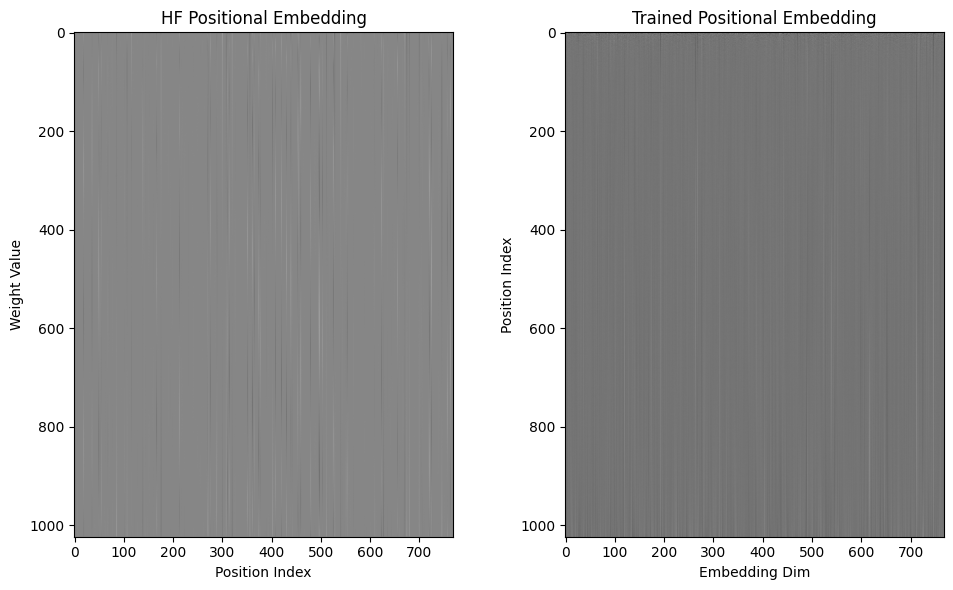

In [22]:
fig, axes  = plt.subplots(1,2,figsize=(10,6))
img1 = axes[0].imshow(sd_hf['transformer.wpe.weight'], cmap="gray")
img2 = axes[1].imshow(state_dict['transformer.wpe.weight'], cmap="gray")
axes[0].set_title("HF Positional Embedding")
axes[0].set_ylabel("Weight Value")
axes[0].set_xlabel("Position Index")

axes[1].set_title("Trained Positional Embedding")
axes[1].set_ylabel("Position Index")
axes[1].set_xlabel("Embedding Dim")
plt.tight_layout()
plt.show()

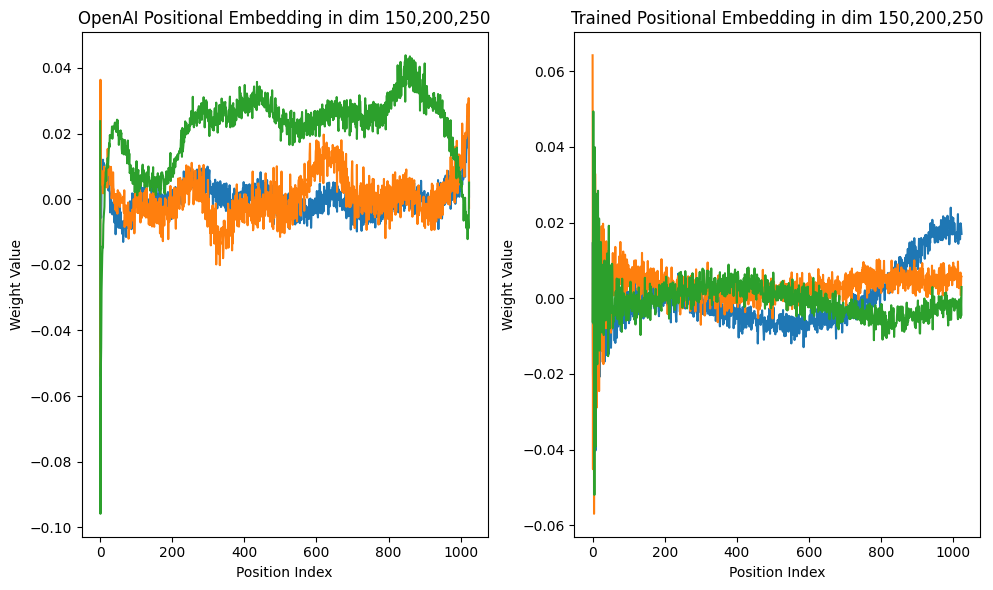

In [23]:
fig, axes  = plt.subplots(1,2,figsize=(10,6))
axes[0].plot(sd_hf['transformer.wpe.weight'][:,150])
axes[0].plot(sd_hf['transformer.wpe.weight'][:,200])
axes[0].plot(sd_hf['transformer.wpe.weight'][:,250])
axes[1].plot(state_dict['transformer.wpe.weight'][:,150])
axes[1].plot(state_dict['transformer.wpe.weight'][:,200])
axes[1].plot(state_dict['transformer.wpe.weight'][:,250])

axes[0].set_title("OpenAI Positional Embedding in dim 150,200,250")
axes[0].set_ylabel("Weight Value")
axes[0].set_xlabel("Position Index")

axes[1].set_title("Trained Positional Embedding in dim 150,200,250")
axes[1].set_ylabel("Weight Value")
axes[1].set_xlabel("Position Index")
plt.tight_layout()
plt.show()

# Attention Layer

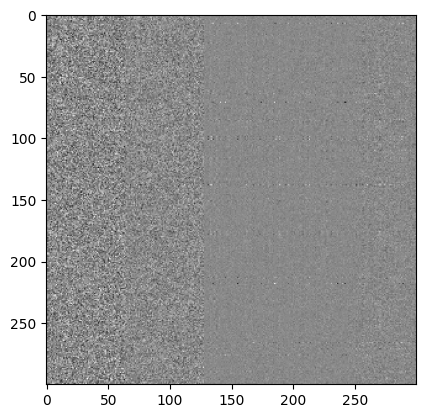

In [24]:
plt.imshow(sd_hf['transformer.h.1.attn.c_attn.weight'][:300,:300], cmap="gray")

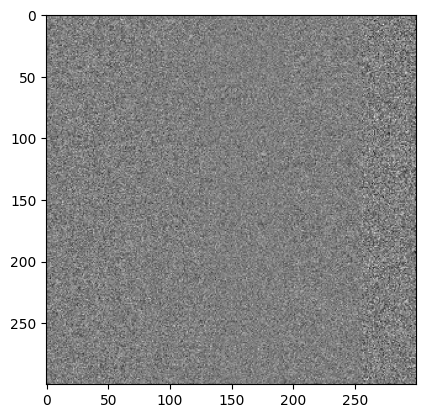

In [25]:
#Trained Model
plt.imshow(state_dict['transformer.h.1.attn.c_attn.weight'].T[:300,:300], cmap="gray")

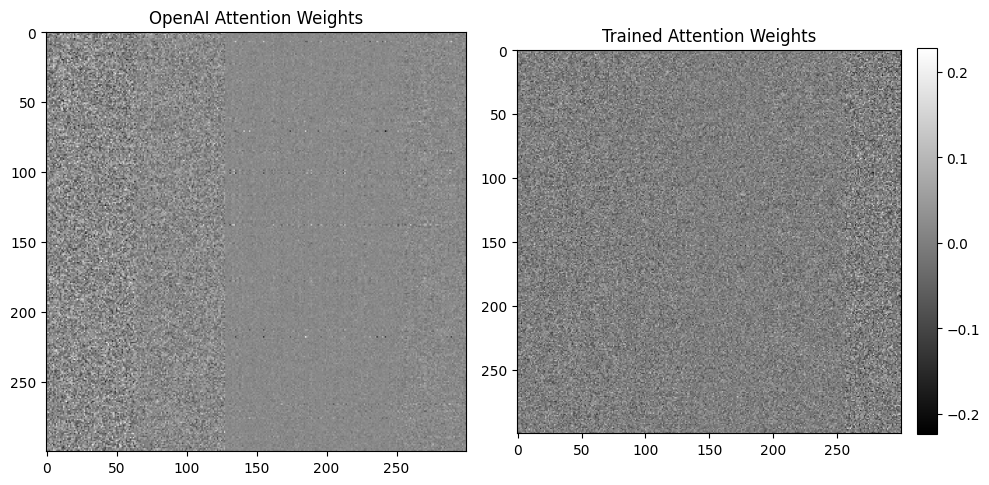

In [26]:
fig, axes  = plt.subplots(1,2,figsize=(10,6))
img1 = axes[0].imshow(sd_hf['transformer.h.1.attn.c_attn.weight'][:300,:300], cmap="gray")
img2 = axes[1].imshow(state_dict['transformer.h.1.attn.c_attn.weight'].T[:300,:300], cmap="gray")
axes[0].set_title("OpenAI Attention Weights")

axes[1].set_title("Trained Attention Weights")
fig.colorbar(img2, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Training Loss and HellaSwag

In [27]:
import numpy as np
%matplotlib inline

min training loss 2.9287
min training loss 3.0784
Max Hellaswag eval: 0.3058


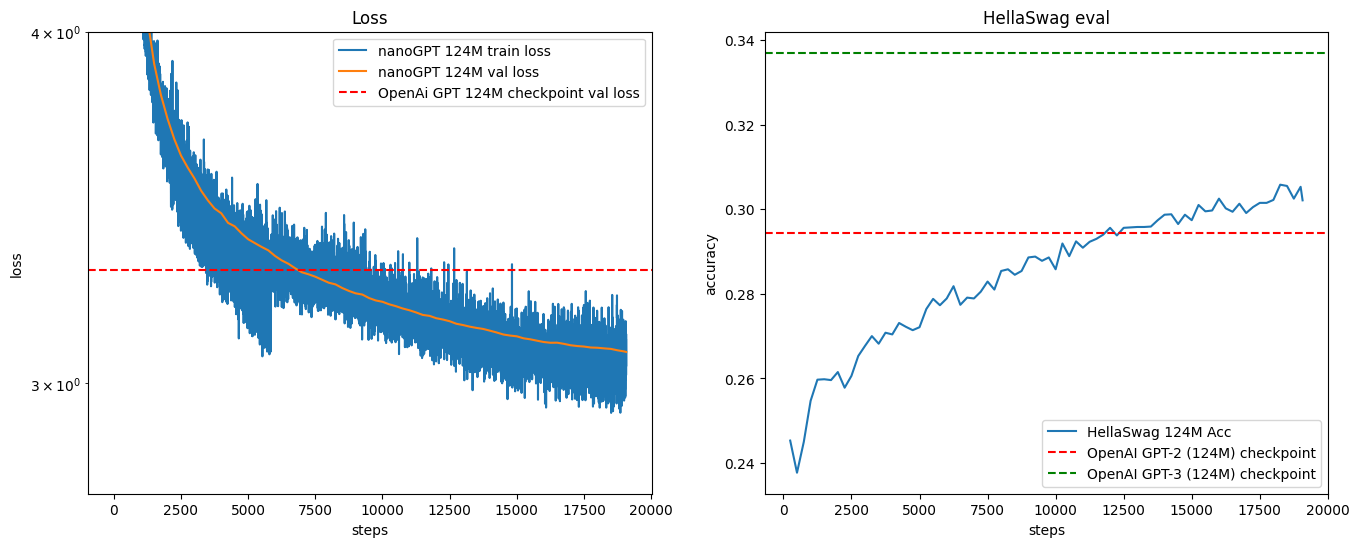

In [28]:
sz = "124M"
loss_baseline={
    "124M":3.2924
}[sz]
hella2_baseline = { # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = { # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

with open("log/log.txt") as f:
    lines = f.readlines()
#parse the log file

streams = {}
for l in lines:
    step,stream, val = l.strip().split()
    if stream not in streams:
        streams[stream] = {}
    streams[stream][int(step)] = float(val)
#Convert each stream from step:val to steps[], vals[]
streams_xy = {}
for k,v in streams.items():
    #get all step, val items
    xy = sorted(list(v.items()))
    streams_xy[k] = list(zip(*xy))

plt.figure(figsize=(16,6))
#panel one plot losses 
plt.subplot(121)
xs,ys = streams_xy["train"] #training loss
ys = np.array(ys)
plt.plot(xs,ys, label=f"nanoGPT {sz} train loss")
print(f"min training loss {min(ys)}")
xs,ys = streams_xy["val"] #training loss
ys = np.array(ys)
plt.plot(xs,ys, label=f"nanoGPT {sz} val loss")
print(f"min training loss {min(ys)}")
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color="r", linestyle="--", label=f"OpenAi GPT {sz} checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale("log")
plt.ylim(top=4.)
plt.legend()
plt.title("Loss")
plt.subplot(122)
xs,ys = streams_xy["hella"] #training loss
ys = np.array(ys)
plt.plot(xs,ys, label=f"HellaSwag {sz} Acc")
if hella2_baseline:
    plt.axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint")
if hella3_baseline:
    plt.axhline(y=hella3_baseline, color='g', linestyle='--', label=f"OpenAI GPT-3 ({sz}) checkpoint")
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.legend()
plt.title("HellaSwag eval")
print("Max Hellaswag eval:", max(ys))